/var/folders/q7/cvkqk2591x3cmrgbm452xsgw0000gn/T/ipykernel_75490/1286911774.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ConditionLabel", y=resid_col, data=df_final, palette=palette, showfliers=False, ax=ax)
/var/folders/q7/cvkqk2591x3cmrgbm452xsgw0000gn/T/ipykernel_75490/1286911774.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ConditionLabel", y=resid_col, data=df_final, palette=palette, showfliers=False, ax=ax)
/var/folders/q7/cvkqk2591x3cmrgbm452xsgw0000gn/T/ipykernel_75490/1286911774.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same eff

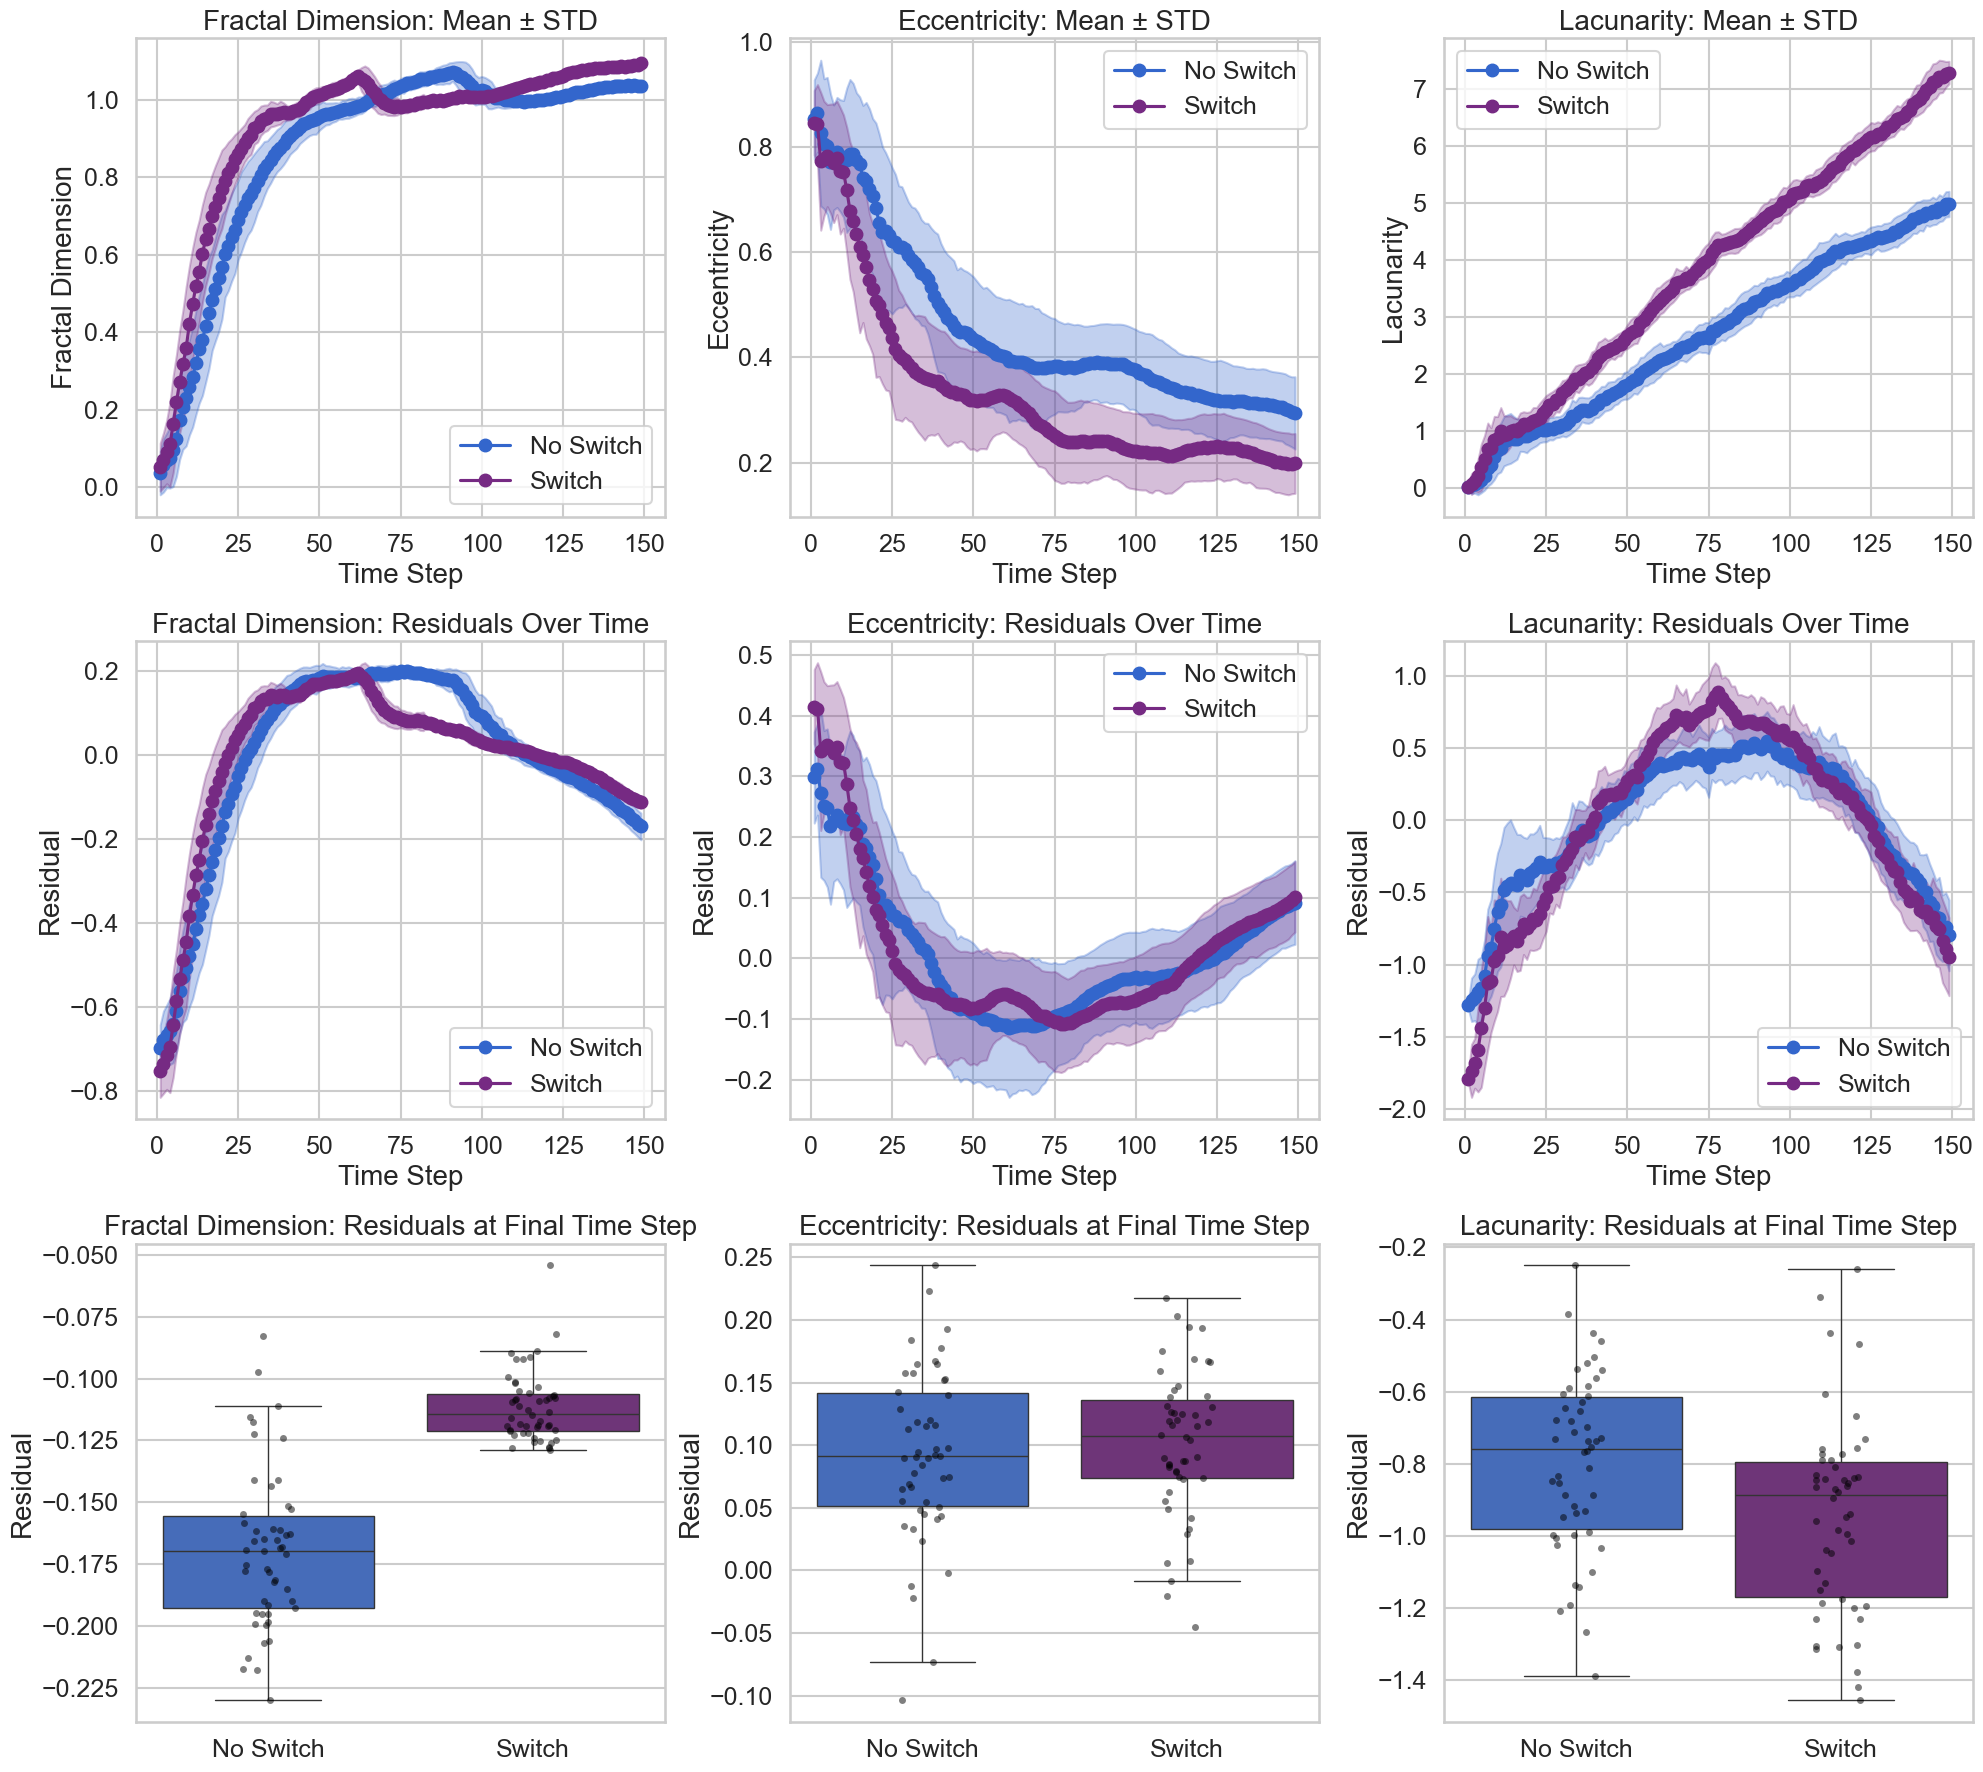


Final Residual Statistics at Final Time Step:

Fractal Dimension (No Switch): Mean = -0.169, Std = 0.032
Fractal Dimension (Switch): Mean = -0.111, Std = 0.014
Fractal Dimension: Mann–Whitney U = 184.00, p = 2.05e-13

Eccentricity (No Switch): Mean = 0.092, Std = 0.069
Eccentricity (Switch): Mean = 0.102, Std = 0.058
Eccentricity: Mann–Whitney U = 1135.00, p = 0.43

Lacunarity (No Switch): Mean = -0.796, Std = 0.245
Lacunarity (Switch): Mean = -0.944, Std = 0.270
Lacunarity: Mann–Whitney U = 1675.00, p = 0.00343



In [14]:
# ========================================
# Morphological Metric Visualization Script
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

# ---------- Load Data ----------
df = pd.read_csv("base_targeted_continuous.csv")
df["GridIndex"] = df["GridIndex"].astype(int)

# ---------- Define Constants ----------
metrics = ["FractalDimension", "Eccentricity", "Lacunarity"]
metric_titles = {
    "FractalDimension": "Fractal Dimension",
    "Eccentricity": "Eccentricity",
    "Lacunarity": "Lacunarity"
}
label_map = {0: "No Switch", 1: "Switch"}
colors = {0: "#3366cc", 1: "#762a83"}
palette = {"No Switch": "#3366cc", "Switch": "#762a83"}

# ---------- Compute Residuals ----------
for metric in metrics:
    df[f"{metric}_resid"] = np.nan
    for grid_idx in [0, 1]:
        subset = df[df["GridIndex"] == grid_idx].copy()
        model = smf.ols(f"{metric} ~ TumorCellCount", data=subset).fit()
        df.loc[subset.index, f"{metric}_resid"] = model.resid

# ---------- Subset Final Time Step ----------
final_time = df["TimeStep"].max()
df_final = df[df["TimeStep"] == final_time].copy()
df_final["ConditionLabel"] = df_final["GridIndex"].map(label_map)

# ---------- Set Plotting Style ----------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 18
})

# ---------- Create 3x3 Figure Grid ----------
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

# ---------- Row 1: Metric Mean ± STD Over Time ----------
for i, metric in enumerate(metrics):
    ax = axes[i]
    summary = df.groupby(["TimeStep", "GridIndex"])[metric].agg(["mean", "std"]).reset_index()
    for grid_idx in [0, 1]:
        group = summary[summary["GridIndex"] == grid_idx]
        ax.plot(group["TimeStep"], group["mean"], '-o', color=colors[grid_idx], label=label_map[grid_idx])
        ax.fill_between(group["TimeStep"], group["mean"] - group["std"], group["mean"] + group["std"],
                        color=colors[grid_idx], alpha=0.3)
    ax.set_title(f"{metric_titles[metric]}: Mean ± STD")
    ax.set_xlabel("Time Step")
    ax.set_ylabel(metric_titles[metric])
    ax.legend()

# ---------- Row 2: Residuals Over Time ----------
for i, metric in enumerate(metrics):
    ax = axes[i + 3]
    resid_col = f"{metric}_resid"
    summary = df.groupby(["TimeStep", "GridIndex"])[resid_col].agg(["mean", "std"]).reset_index()
    for grid_idx in [0, 1]:
        group = summary[summary["GridIndex"] == grid_idx]
        ax.plot(group["TimeStep"], group["mean"], '-o', color=colors[grid_idx], label=label_map[grid_idx])
        ax.fill_between(group["TimeStep"], group["mean"] - group["std"], group["mean"] + group["std"],
                        color=colors[grid_idx], alpha=0.3)
    ax.set_title(f"{metric_titles[metric]}: Residuals Over Time")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Residual")
    ax.legend()

# ---------- Row 3: Boxplots at Final Time Step ----------
for i, metric in enumerate(metrics):
    ax = axes[i + 6]
    resid_col = f"{metric}_resid"
    sns.boxplot(x="ConditionLabel", y=resid_col, data=df_final, palette=palette, showfliers=False, ax=ax)
    sns.stripplot(x="ConditionLabel", y=resid_col, data=df_final, color='black', alpha=0.5, ax=ax)
    ax.set_title(f"{metric_titles[metric]}: Residuals at Final Time Step")
    ax.set_xlabel("")
    ax.set_ylabel("Residual")

# ---------- Final Layout ----------
plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.savefig("Combined_3x3_Metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- Print Summary Stats and Tests ----------
print("\nFinal Residual Statistics at Final Time Step:\n")
for metric in metrics:
    resid_col = f"{metric}_resid"
    for grid_idx, label in label_map.items():
        vals = df_final[df_final["GridIndex"] == grid_idx][resid_col]
        print(f"{metric_titles[metric]} ({label}): Mean = {vals.mean():.3f}, Std = {vals.std():.3f}")
    
    # Mann–Whitney U test
    group1 = df_final[df_final["GridIndex"] == 0][resid_col]
    group2 = df_final[df_final["GridIndex"] == 1][resid_col]
    u_stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
    print(f"{metric_titles[metric]}: Mann–Whitney U = {u_stat:.2f}, p = {p_val:.3g}\n")

Successfully loaded dataframe shape: (1498529, 14)


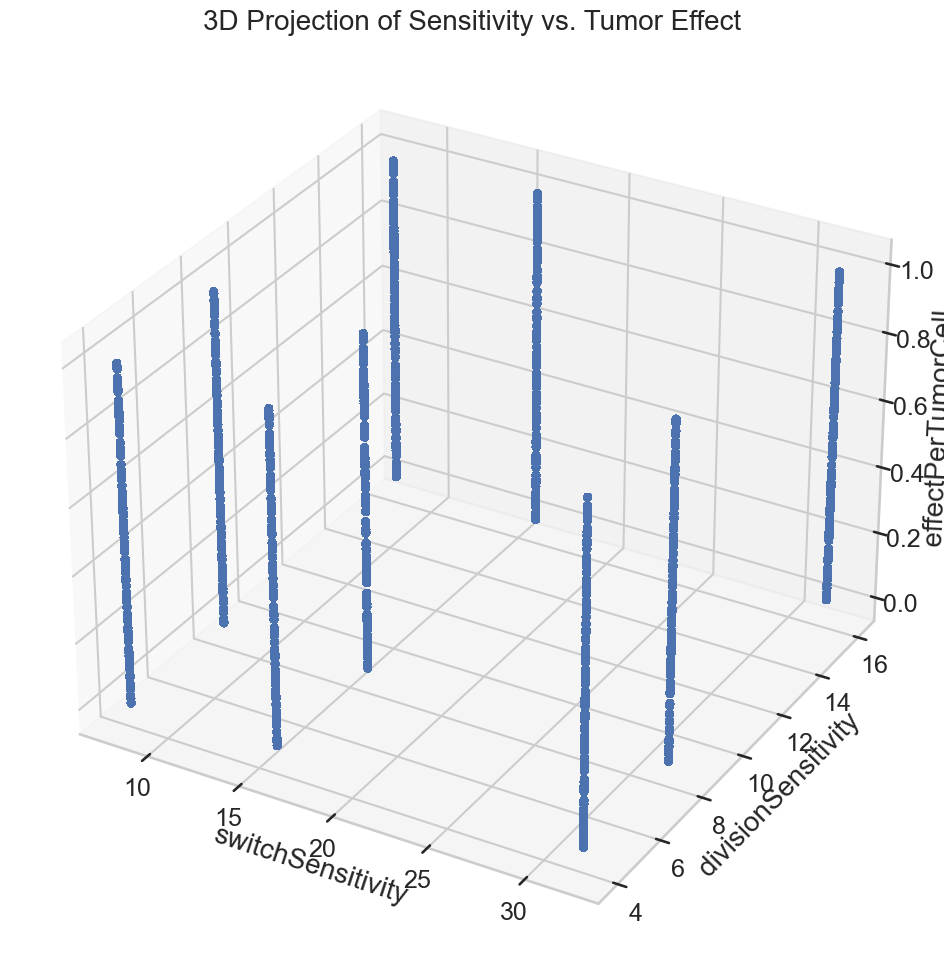

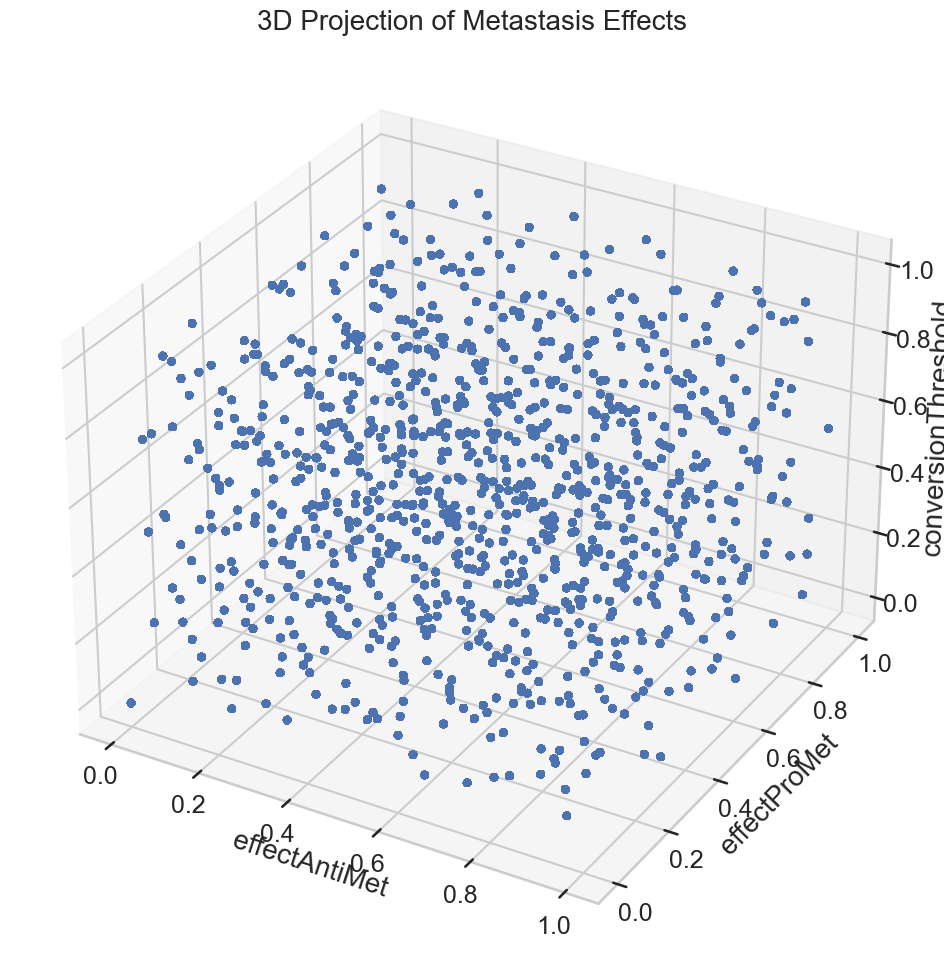

In [15]:
# ========================================
# 3D Parameter Space Visualization Script
# ========================================

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns

# ---------- Load Data ----------
df = pd.read_csv("base_psa.csv", on_bad_lines='skip')
print("Successfully loaded dataframe shape:", df.shape)

# ---------- Clean and Rename Columns ----------
df = df.reset_index()
df = df.rename(columns={"index": "ParamSetIndex"})

desired_columns = [
    "ParamSetIndex", "Replication", "TimeStep", "GridIndex", 
    "effectAntiMet", "effectProMet", "conversionThreshold", 
    "S2", "S4", "effectPerTumorCell", "TumorCellCount", 
    "FractalDimension", "Lacunarity", "Eccentricity"
]
df = df.iloc[:, :len(desired_columns)]
df.columns = desired_columns

# Rename shorthand sensitivity variables
df = df.rename(columns={
    "S2": "switchSensitivity",
    "S4": "divisionSensitivity"
})

# ---------- Define Plotting Function ----------
def plot_3d_scatter(df, x, y, z, title, filename):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(df[x], df[y], df[z], alpha=0.5)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# ---------- Generate 3D Plots ----------
plot_3d_scatter(
    df,
    x="switchSensitivity",
    y="divisionSensitivity",
    z="effectPerTumorCell",
    title="3D Projection of Sensitivity vs. Tumor Effect",
    filename="parameter_sampling_sensitivity_effect.png"
)

plot_3d_scatter(
    df,
    x="effectAntiMet",
    y="effectProMet",
    z="conversionThreshold",
    title="3D Projection of Metastasis Effects",
    filename="parameter_sampling_met_effects.png"
)

/var/folders/q7/cvkqk2591x3cmrgbm452xsgw0000gn/T/ipykernel_75490/3095556887.py:75: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = dunn_df.applymap(lambda p: f"{p:.3f}*" if p < alpha else f"{p:.3f}")
/var/folders/q7/cvkqk2591x3cmrgbm452xsgw0000gn/T/ipykernel_75490/3095556887.py:75: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = dunn_df.applymap(lambda p: f"{p:.3f}*" if p < alpha else f"{p:.3f}")
/var/folders/q7/cvkqk2591x3cmrgbm452xsgw0000gn/T/ipykernel_75490/3095556887.py:75: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = dunn_df.applymap(lambda p: f"{p:.3f}*" if p < alpha else f"{p:.3f}")
/var/folders/q7/cvkqk2591x3cmrgbm452xsgw0000gn/T/ipykernel_75490/3095556887.py:75: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = dunn_df.applymap(lambda p: f"{p:.3f}*" if p < alpha else f"{p:.3f}")


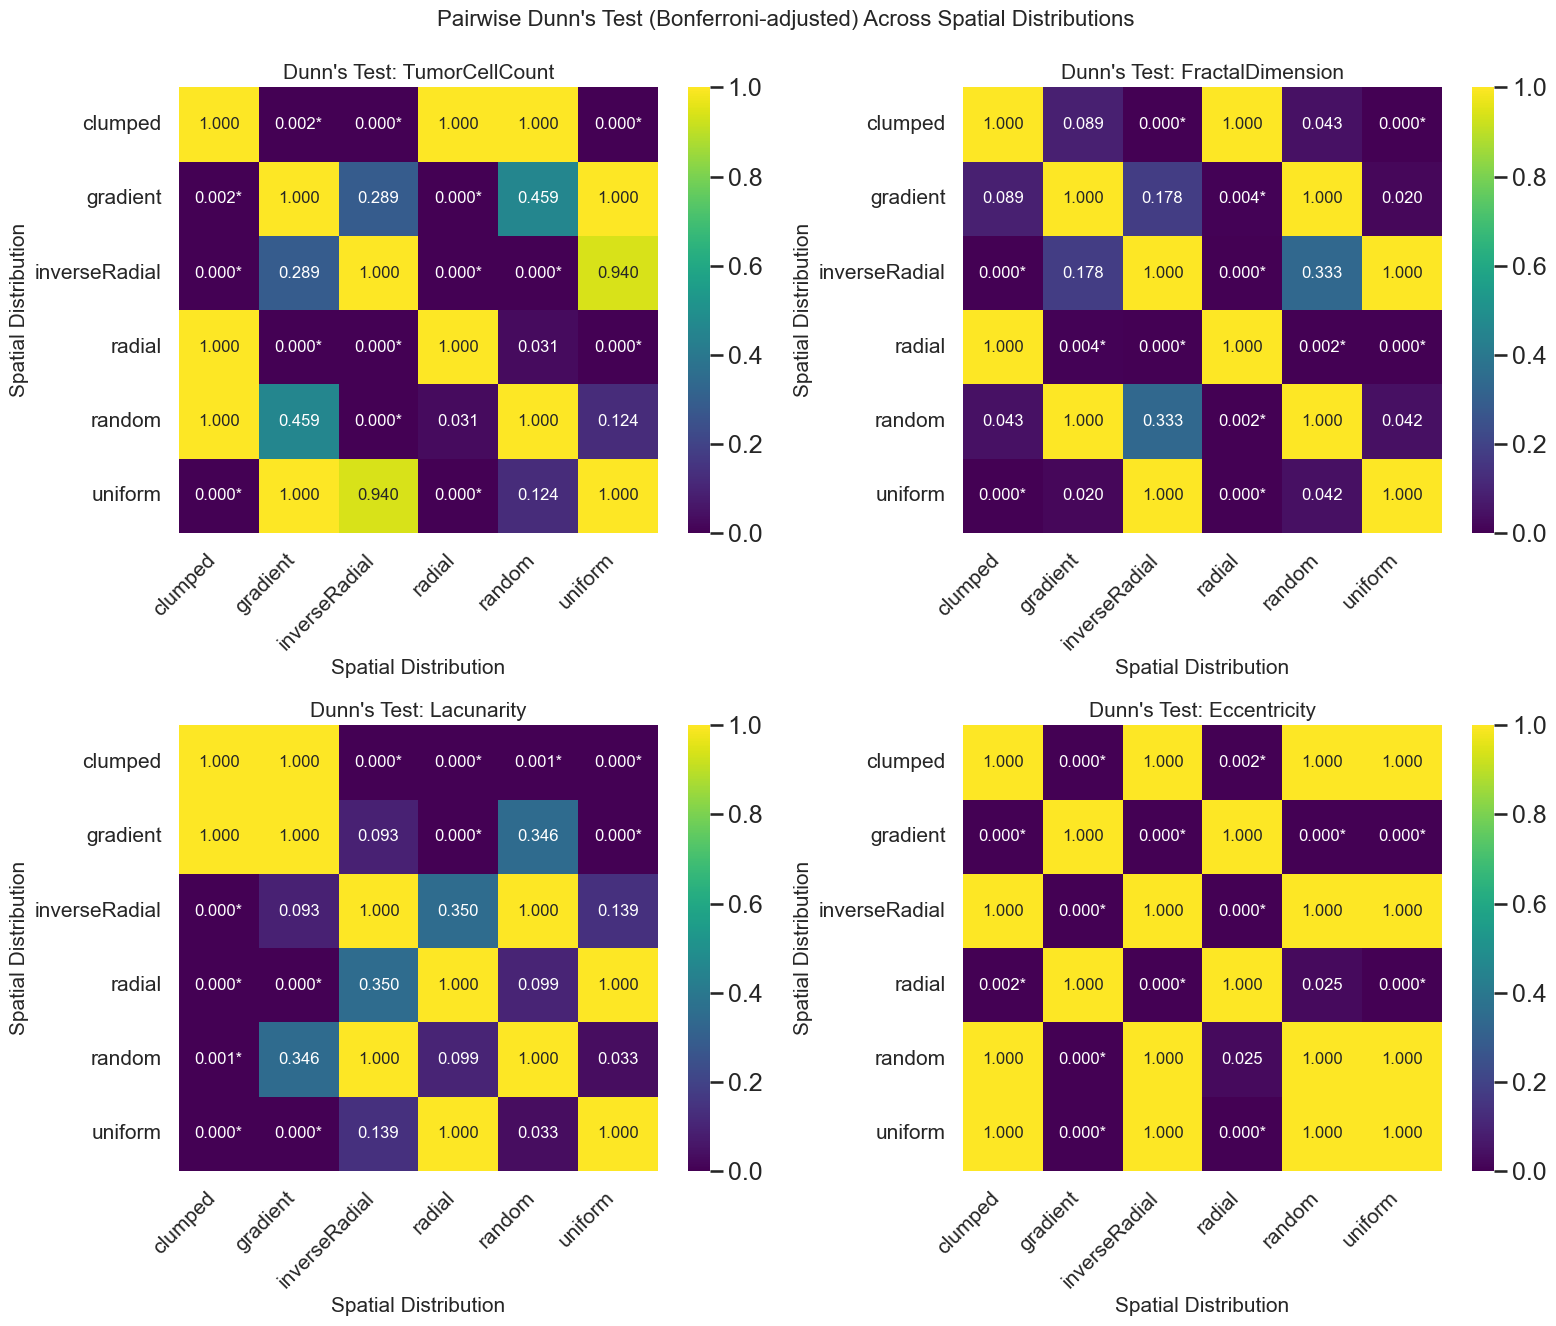

In [40]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------- Load Data --------------------
df = pd.read_csv("spatial_targeted.csv")

# -------------------- Map Spatial Labels --------------------
spatial_map = {
    0: "uniform",
    1: "random",
    2: "clumped",
    3: "inverseRadial",
    4: "radial",
    5: "gradient"
}
df["SpatialDistribution"] = df["GridIndex"].map(spatial_map)

# -------------------- Filter --------------------
df = df[df["TimeStep"] == df["TimeStep"].max()]
df = df.dropna(subset=["FractalDimension", "Eccentricity"])

# -------------------- Stats and Plotting --------------------
metrics = ["TumorCellCount", "FractalDimension", "Lacunarity", "Eccentricity"]
dunn_results_dict = {}
alpha = 0.005
results = []

for metric in metrics:
    normality_p = []
    for label in spatial_map.values():
        data = df[df["SpatialDistribution"] == label][metric]
        if len(data) >= 3:
            _, p = stats.shapiro(data)
            normality_p.append(p)
    
    groups = [df[df["SpatialDistribution"] == label][metric]
              for label in spatial_map.values() if len(df[df["SpatialDistribution"] == label]) >= 3]
    levene_stat, levene_p = stats.levene(*groups) if len(groups) >= 2 else (np.nan, np.nan)

    if normality_p and all(p > 0.05 for p in normality_p) and not np.isnan(levene_p) and levene_p > 0.05:
        test_used = "ANOVA"
        model = smf.ols(f"{metric} ~ C(SpatialDistribution)", data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        overall_p = anova_table["PR(>F)"][0]
        posthoc = pairwise_tukeyhsd(df[metric], df["SpatialDistribution"]).summary()
    else:
        test_used = "Kruskal-Wallis"
        _, overall_p = stats.kruskal(*groups)
        dunn_df = sp.posthoc_dunn(df, val_col=metric, group_col="SpatialDistribution", p_adjust="bonferroni")
        dunn_results_dict[metric] = dunn_df
        posthoc = dunn_df

    results.append({
        "Metric": metric,
        "Test Used": test_used,
        "Overall p-value": overall_p,
        "Post-hoc Results": posthoc
    })

# -------------------- Plot 2×2 Heatmap Grid --------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    if metric in dunn_results_dict:
        dunn_df = dunn_results_dict[metric].astype(float)
        annot = dunn_df.applymap(lambda p: f"{p:.3f}*" if p < alpha else f"{p:.3f}")
        sns.heatmap(
            dunn_df,
            annot=annot,
            fmt='',
            cmap="viridis",
            vmin=0,
            vmax=1,
            ax=ax,
            cbar=True,
            annot_kws={"fontsize": 12}
        )
        ax.set_title(f"Dunn's Test: {metric}", fontsize=15)
        ax.set_xlabel("Spatial Distribution", fontsize=15)
        ax.set_ylabel("Spatial Distribution", fontsize=15)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=15)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
    else:
        ax.axis("off")

plt.suptitle("Pairwise Dunn's Test (Bonferroni-adjusted) Across Spatial Distributions", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("DunnTest_2x2_PublicationReady.png", dpi=600, bbox_inches="tight")
plt.show()

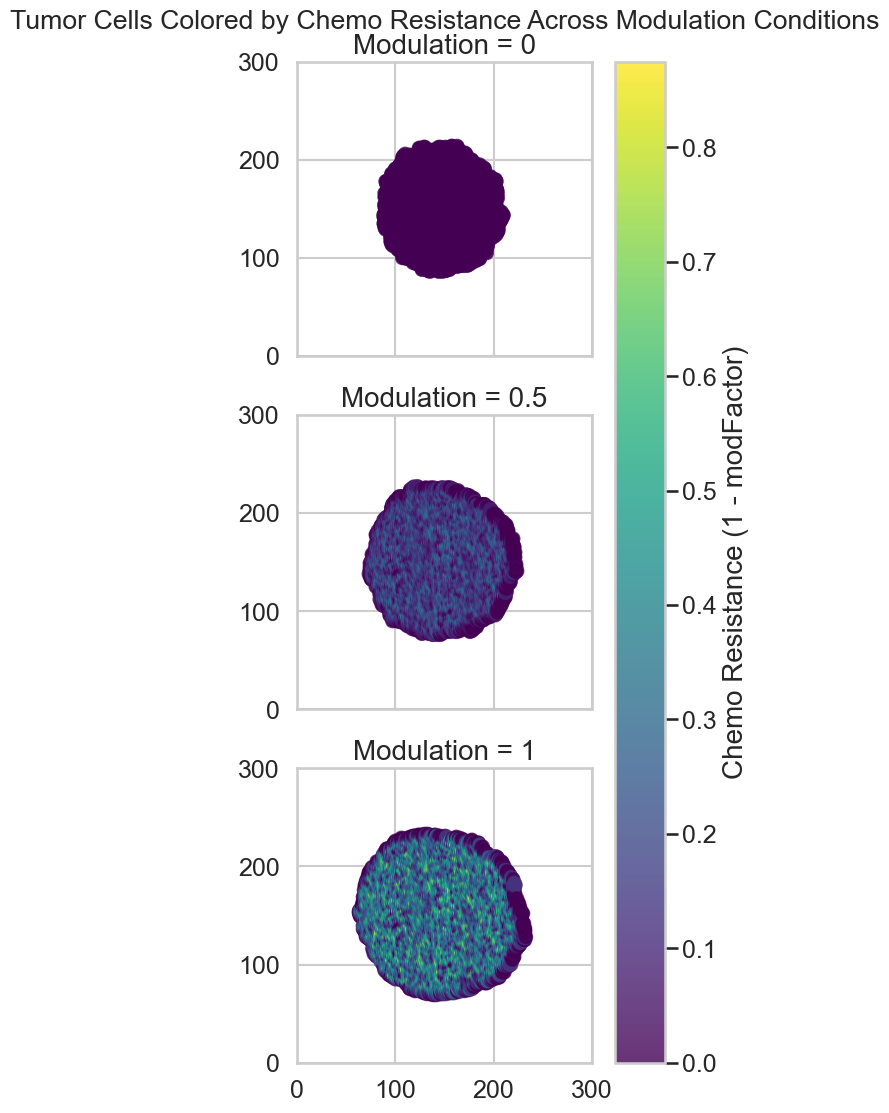

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV files (assume each has columns: 'x', 'y', 'modFactor')
df0 = pd.read_csv("tumorMod_0.0.csv")
df05 = pd.read_csv("tumorMod_0.5.csv")
df1 = pd.read_csv("tumorMod_1.0.csv")

# Compute resistance for each dataframe: resistance = 1 - modFactor
df0['resistance'] = 1.0 - df0['modFactor']
df05['resistance'] = 1.0 - df05['modFactor']
df1['resistance'] = 1.0 - df1['modFactor']

# Combine all resistance values to set a common color scale (vmin and vmax)
all_res = pd.concat([df0['resistance'], df05['resistance'], df1['resistance']])
vmin = all_res.min()
vmax = all_res.max()

# Create subplots arranged vertically (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(6, 13), sharex=True, sharey=True)

titles = ["Modulation = 0", "Modulation = 0.5", "Modulation = 1"]

# Loop over each subplot, plotting the tumor cell positions colored by resistance
for ax, df, title in zip(axes, [df0, df05, df1], titles):
    sc = ax.scatter(df['x'], df['y'], c=df['resistance'], cmap='viridis',
                    vmin=vmin, vmax=vmax, alpha=0.8)
    ax.set_title(title)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 300)
    ax.set_aspect('equal')

# Add a single shared colorbar for all subplots
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation="vertical")
cbar.set_label("Chemo Resistance (1 - modFactor)")

plt.suptitle("Tumor Cells Colored by Chemo Resistance Across Modulation Conditions", y=0.92)
plt.show()

Successfully loaded dataframe shape: (1498529, 14)
Averaged data shape: (9990, 14)
count    999.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
Name: count, dtype: float64
Series([], Name: count, dtype: int64)
Completely missing sets: [11]
Averaged data shape: (999, 14)


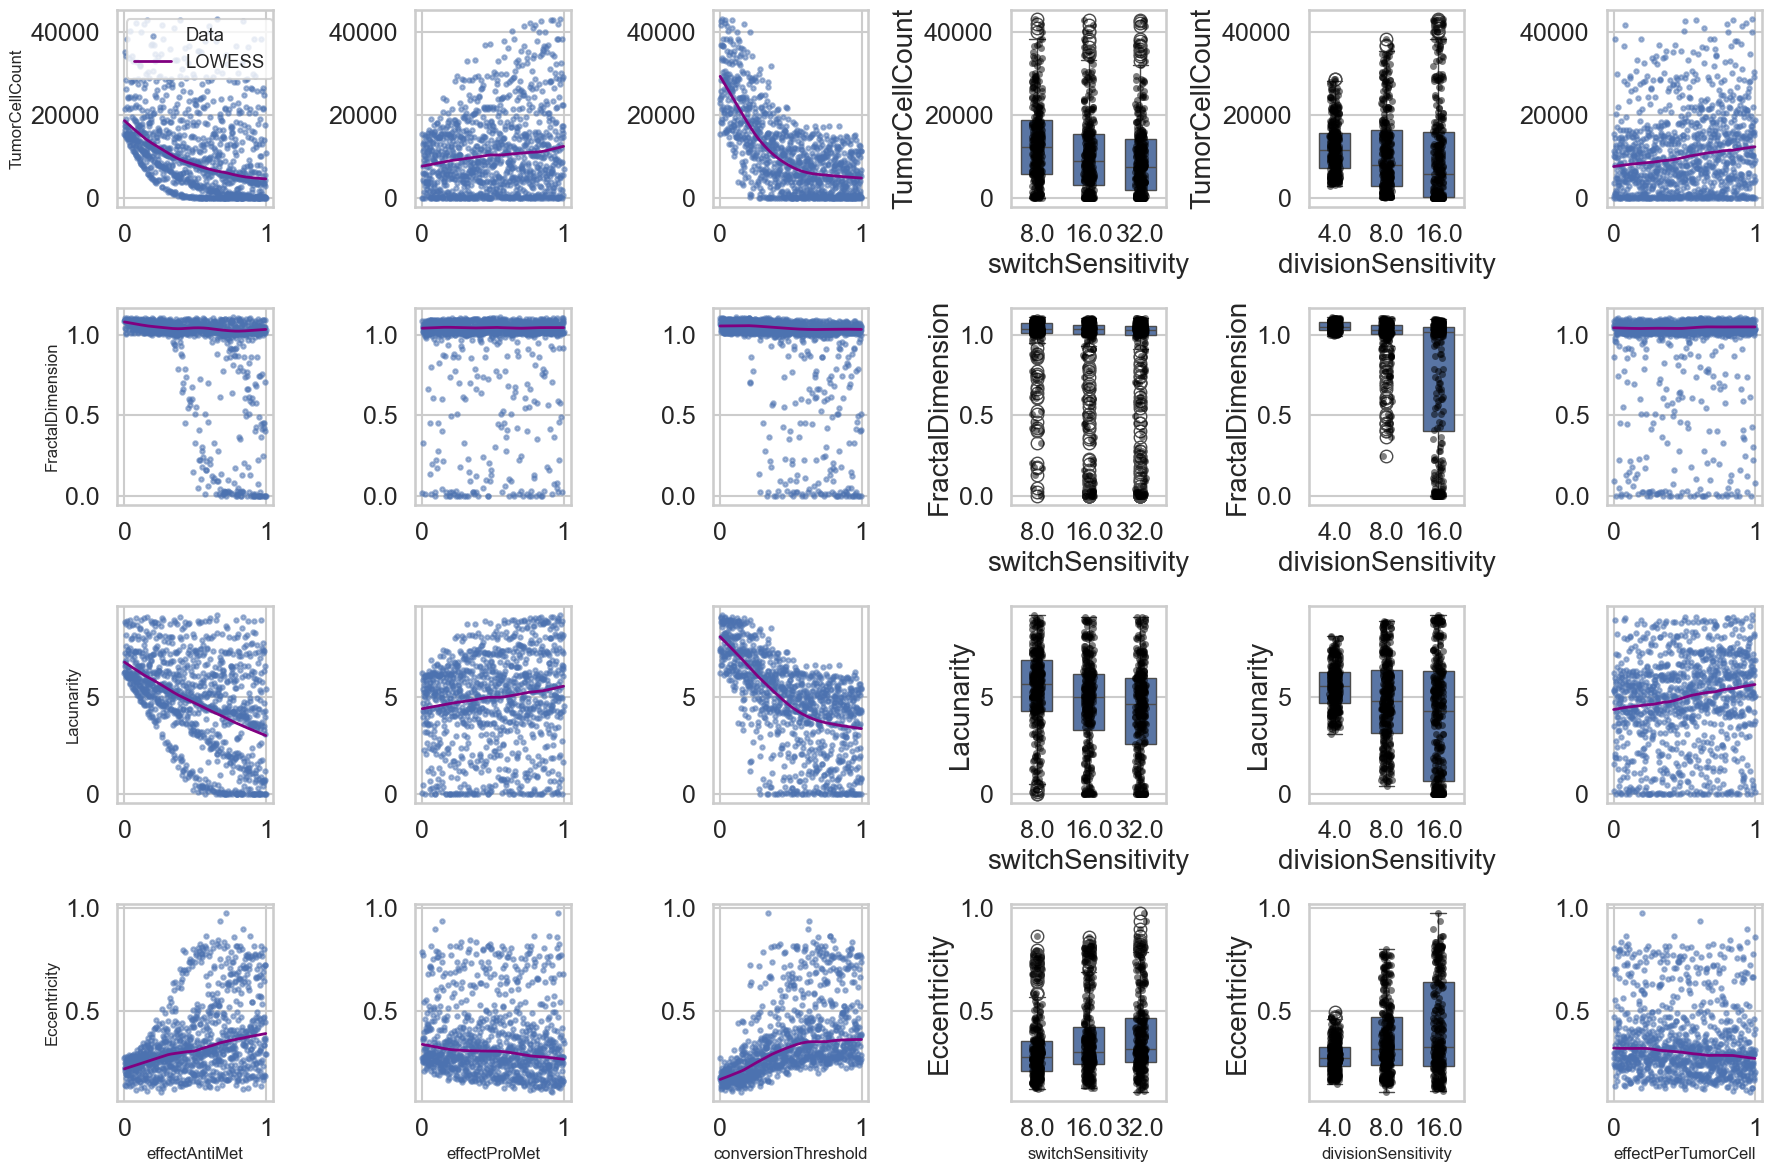

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv 
# Load the CSV, skipping rows with formatting issues
df = pd.read_csv("base_psa.csv", on_bad_lines='skip')

# Print dataframe shape to confirm successful loading
print("Successfully loaded dataframe shape:", df.shape)

df = df.reset_index()
df = df.rename(columns={"index": "ParamSetIndex"})
desired_columns = ["ParamSetIndex", "Replication", "TimeStep", "GridIndex", 
                   "effectAntiMet", "effectProMet", "conversionThreshold", 
                   "S2", "S4", "effectPerTumorCell", "TumorCellCount", 
                   "FractalDimension", "Lacunarity", "Eccentricity"]

# Reassign the columns to these names (assuming the DataFrame columns are in the right order)
df = df.iloc[:, :len(desired_columns)]  # take only the first 14 columns
df.columns = desired_columns
df = df.rename(columns={"S2": "switchSensitivity"})
df = df.rename(columns={"S4": "divisionSensitivity"})
df.head()

# Filter for the final time step and drop rows with missing key metrics
final_time = df["TimeStep"].max()
df_filtered = df[df["TimeStep"] == final_time].copy()

print("Averaged data shape:", df_filtered.shape)

counts = df_filtered["ParamSetIndex"].value_counts()
print(counts.describe())

under_sampled = counts[counts < 10]
print(under_sampled)

expected = set(range(1000))
actual = set(df_filtered["ParamSetIndex"].unique())
missing_sets = sorted(list(expected - actual))
print("Completely missing sets:", missing_sets)

df_avg = df_filtered.groupby("ParamSetIndex").mean().reset_index()
print("Averaged data shape:", df_avg.shape)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# Example parameter and output lists
param_list = ["effectAntiMet", "effectProMet", 
              "conversionThreshold", "switchSensitivity", "divisionSensitivity", "effectPerTumorCell"]
output_list = ["TumorCellCount", "FractalDimension", "Lacunarity", "Eccentricity"]

# Threshold for deciding if a parameter is discrete (adjust as needed)
discrete_threshold = 10

fig, axes = plt.subplots(nrows=len(output_list), ncols=len(param_list), 
                         figsize=(18, 12),
                         sharey=False)

# Loop over each output (row)
for row_idx, output_name in enumerate(output_list):
    # Loop over each parameter (column)
    for col_idx, param_name in enumerate(param_list):
        ax = axes[row_idx, col_idx]
        x = df_avg[param_name].values
        y = df_avg[output_name].values
        
        unique_vals = np.unique(x)
        
        # If parameter is discrete, use a boxplot (or jittered scatter)
        if len(unique_vals) < discrete_threshold:
            # Create a temporary DataFrame for easier grouping
            temp_df = pd.DataFrame({param_name: x, output_name: y})
            # Sort the discrete values for consistent plotting order
            order = np.sort(unique_vals)
            sns.boxplot(x=param_name, y=output_name, data=temp_df, order=order, ax=ax, width=0.6)
            # Optionally overlay swarmplot for individual data points
            sns.stripplot(x=param_name, y=output_name, data=temp_df, order=order, ax=ax, color='black', alpha=0.5)
        else:
            # For continuous parameters, do a scatter plot and LOWESS smoothing
            ax.scatter(x, y, alpha=0.5, s=10, label="Data")
            lowess_frac = 0.3  # Adjust as needed
            lowess_results = sm.nonparametric.lowess(y, x, frac=lowess_frac)
            lowess_x, lowess_y = lowess_results[:, 0], lowess_results[:, 1]
            ax.plot(lowess_x, lowess_y, color='purple', linewidth=2, label="LOWESS")
        
        # Set x-label only on bottom row
        if row_idx == len(output_list) - 1:
            ax.set_xlabel(param_name, fontsize=12)
        # Set y-label only on leftmost column
        if col_idx == 0:
            ax.set_ylabel(output_name, fontsize=12)
        # Add legend only for first plot to avoid clutter
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize="small")

plt.tight_layout()
plt.show()